In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

x,y=make_circles(n_samples=500, factor=0.3, noise=0.1,random_state=42)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [5]:
linear_svm=SVC(kernel='linear',C=1)
linear_svm.fit(x_scaled,y)
linear_acc=linear_svm.score(x_scaled,y)
rbf_svm=SVC(kernel='rbf',C=1,gamma='scale')
rbf_svm.fit(x_scaled,y)
rbf_acc=rbf_svm.score(x_scaled,y)
print("--- SVM Technique Accuracy Comparison ---")
print(f"Linear Kernel Accuracy: {linear_acc * 100:.2f}% (Expect a low score!)")
print(f"RBF Kernel Accuracy   : {rbf_acc * 100:.2f}% (Expect near perfection!)")


--- SVM Technique Accuracy Comparison ---
Linear Kernel Accuracy: 67.20% (Expect a low score!)
RBF Kernel Accuracy   : 100.00% (Expect near perfection!)


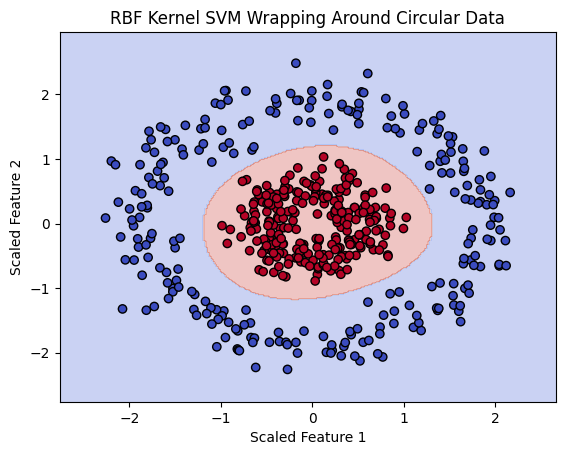

In [8]:

x_min, x_max = x_scaled[:, 0].min() - 0.5, x_scaled[:, 0].max() + 0.5
y_min, y_max = x_scaled[:, 1].min() - 0.5, x_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("RBF Kernel SVM Wrapping Around Circular Data")
plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.show()